# Vertically Checked Tilt Analysis

Main summary plots for vertically checked tilt distance.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths)
df_eddies = tilt.add_time_coordinates(df_eddies)
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=False)

n_profiles = len(df_eddies)
n_tilt = df_eddies.TiltDis.notna().sum()
print(f"Eddy-days: {n_profiles:,}")
print(f"Tilt-checked eddy-days: {n_tilt:,} ({n_tilt / n_profiles:.1%})")
df_eddies.head()


Eddy-days: 127,426
Tilt-checked eddy-days: 105,621 (82.9%)


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,PV_grad_plan_theta,PV_grad_topo_mag,PV_grad_topo_theta,PV_grad_mag,PV_grad_theta,dtheta_PV_grad,dtheta_PV_grad_topo,dtheta_PV_grad_plan,Ro,topo_plan_ratio
0,1,1462,CE,152.716333,-38.866383,171,26,474.560686,127.605656,-0.000032,...,180.0,7.895770e-15,276.419583,8.377964e-15,249.477659,NaN,NaN,NaN,0.354182,0.726103
1,1,1463,CE,152.836206,-38.814279,173,28,482.821993,136.635735,-0.000041,...,180.0,8.369217e-15,338.758961,5.003859e-15,322.702556,NaN,NaN,NaN,0.443995,0.784289
2,1,1464,CE,152.905198,-38.816261,175,28,488.606048,138.480541,-0.000035,...,180.0,1.387610e-15,269.460879,4.072159e-15,199.921986,NaN,NaN,NaN,0.386802,-1.011466
3,1,1465,CE,152.719389,-38.902070,171,25,475.960098,123.953440,-0.000020,...,180.0,8.747232e-15,241.329311,1.109900e-14,223.747489,136.239717,153.821539,92.492228,0.217021,0.828186
4,1,1466,CE,152.753007,-38.935135,172,25,479.803789,121.483614,-0.000026,...,180.0,8.095121e-15,207.295183,1.162087e-14,198.629320,93.326931,101.992795,74.697612,0.285414,0.751478


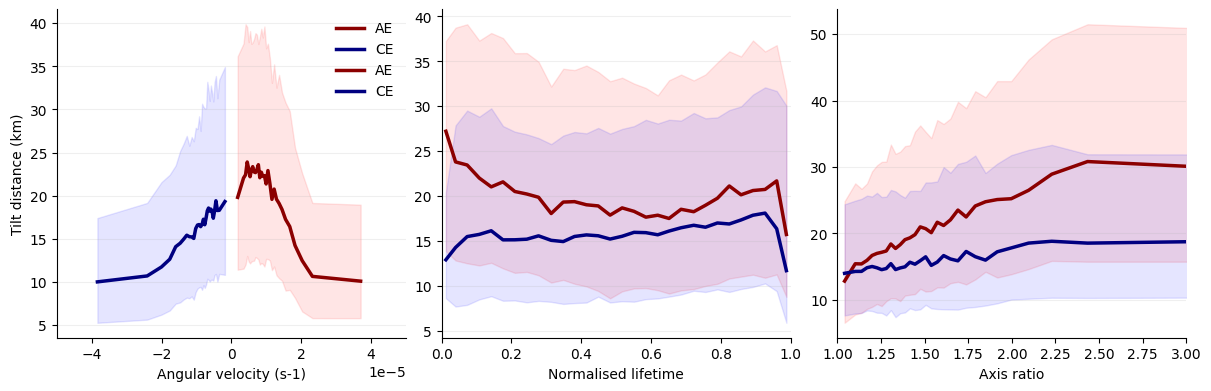

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)

ax = tilt.binned_tilt_panel(axs[0], df_eddies[df_eddies.Cyc=='AE'], "Omega", "", ylabel="Tilt distance (km)")
tilt.binned_tilt_panel(ax, df_eddies[df_eddies.Cyc=='CE'], "Omega", "Angular velocity (s-1)", ylabel="Tilt distance (km)")
ax.set_xlim(-5e-5, 5e-5)
tilt.binned_tilt_panel(axs[1], df_eddies, "norm_time", "Normalised lifetime")
axs[1].set_xlim(0, 1)
tilt.binned_tilt_panel(axs[2], df_eddies, "AR", "Axis ratio")
axs[2].set_xlim(1, 3)
axs[0].legend(frameon=False)
plt.show()


In [ ]:
# season_df = df_eddies.copy()
# if "Date" in season_df.columns:
#     season_df = tilt.add_season(season_df)
#     order = ["DJF", "MAM", "JJA", "SON"]
#     data = [season_df.loc[season_df.Season == s, "TiltDis"].dropna() for s in order]
#     fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
#     ax.boxplot(data, tick_labels=order, showfliers=False, patch_artist=True)
#     ax.set_xlabel("Season")
#     ax.set_ylabel("Tilt distance (km)")
#     ax.grid(True, axis="y", alpha=0.25)
#     plt.show()
# else:
#     print("No Date column available for seasonal summary.")


In [4]:
summary = (
    df_eddies
    .groupby("Cyc")
    .agg(eddy_days=("TiltDis", "size"), tilt_days=("TiltDis", "count"), median_tilt_km=("TiltDis", "median"), mean_tilt_km=("TiltDis", "mean"))
)
summary


,eddy_days,tilt_days,median_tilt_km,mean_tilt_km
Cyc,,,,
AE,64952,53607,19.609894,26.080512
CE,62474,52014,16.008249,21.584768


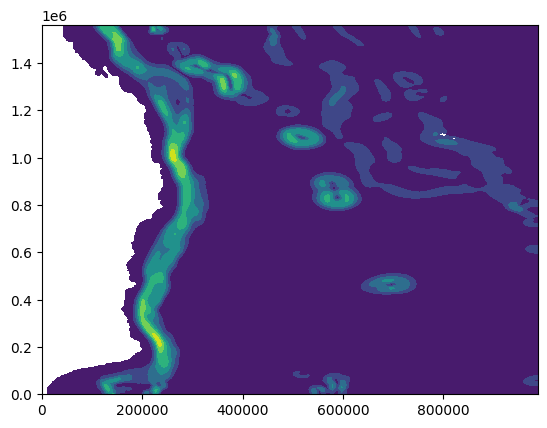

In [5]:
dhdx, dhdy = tilt.phys_grad(grid.h, grid.X_grid * 1e3, grid.Y_grid * 1e3, grid.mask_rho)
plt.contourf(grid.X_grid * 1e3, grid.Y_grid * 1e3, np.hypot(dhdx, dhdy))